In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from utils.participant_data import load_participant
from utils.catchtrials import CatchTrials
from utils.gazedata import GazeData

In [25]:
participant_nr = "05"

DATA_ROOT = "data"
PARTICIPANT_FOLDER_PATTERN = f"participant_{participant_nr}"

df_pos = pd.read_csv("data/sentence_position_def.csv") # changed it so that we have the new sentence positioning

In [26]:
from utils.pres_mapper import PresentationMapper

mapper = PresentationMapper(
    real_order_path="data/sentences.js",
    exp_order_path=f"{DATA_ROOT}/{PARTICIPANT_FOLDER_PATTERN}/sentence_order_{participant_nr}.csv",
)

# sentence_position_def.csv already contains presentation_index,
# so adapt it to add the corresponding real_index column.
df_pos_mapped = mapper.adapt_df_pos(df_pos)

assert df_pos_mapped["presentation_index"].notna().all()
assert df_pos_mapped["real_index"].notna().all()

df_pos_mapped["presentation_index"] = df_pos_mapped["presentation_index"].astype(int)


[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/participant_05/sentence_order_05.csv
  Loaded 96 sentences from real_order
  First sentence : 'Sous le sapin, Alex trouve un cadeau mystérieux.'
  Last sentence  : 'Elle fait tomber son gâteau en le sortant du four.'
  exp_order shape : (96, 4)
  exp_order columns : ['real_index', 'presentation_index', 'first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                        first  real_index
                  0  Nous nous disputons encore pour la même histoire de ménage.          90
                  1 La lecture du soir s'étire dans le calme de la bibliothèque.          66
                  2       On finissait de manger et on discutait tranquillement.          79
                  3           Elle fait tomber son gâteau en le sortant du four.          95
                  4   Nous profitons d'un pique-nique ensoleillé au bord du la

In [27]:
df_pos_mapped.head()

,presentation_index,part_nr,line_idx,text,top,bottom,left,right,real_index
0,0,1,0,Sophie arrive au bureau avec un sourire énigma...,393.0,433.0,284.0,1636.0,90
1,0,2,0,Elle raconte qu'elle attend un bébé.,560.0,600.0,492.0,1428.0,90
2,1,1,0,Mafalda ne voit plus son fils dans l'eau de la...,393.0,433.0,297.0,1623.0,66
3,1,2,0,"Son mari la rassure, il ne peut pas être très ...",560.0,600.0,297.0,1623.0,66
4,2,1,0,La lecture du soir s'étire dans le calme de la...,393.0,433.0,180.0,1740.0,79


# Catch trials analysis

In [28]:

p = load_participant(participant_nr)   # or whatever participant_nr you're on

p.calibration        # dict from the JSON
p.catch_trials        # DataFrame
p.experiment           # DataFrame
p.gaze                 # DataFrame
p.sentence_order       # DataFrame

CatchTrials.from_dataframe(p.catch_trials).summary()  # reuse your existing analysis on just this one

Total trials     : 9
Unique sentences : 9
Percent correct  : 100.0%
Mean RT          : 6353.7 ms

RT by correctness:
          count     min      q1  median      q3      max
response                                                
correct     9.0  4240.0  5007.0  5312.0  6704.0  10256.0
Catch types      : 
catch_type
unseen    6
seen      3
Name: count, dtype: int64


# Gaze analysis

In [29]:
print(f"Shape: {p.gaze.shape}")
print(f"\nColumns: {list(p.gaze.columns)}")
print(f"\nDtypes:\n{p.gaze.dtypes}")

Shape: (62211, 1)

Columns: ['CNT\tTIME\tTIME_TICK\tFPOGX\tFPOGY\tFPOGS\tFPOGD\tFPOGID\tFPOGV\tLPOGX\tLPOGY\tLPOGV\tRPOGX\tRPOGY\tRPOGV\tBPOGX\tBPOGY\tBPOGV\tLPCX\tLPCY\tLPD\tLPS\tLPV\tRPCX\tRPCY\tRPD\tRPS\tRPV\tLEYEX\tLEYEY\tLEYEZ\tLPUPILD\tLPUPILV\tREYEX\tREYEY\tREYEZ\tRPUPILD\tRPUPILV\tCX\tCY\tCS\tUSER']

Dtypes:
CNT\tTIME\tTIME_TICK\tFPOGX\tFPOGY\tFPOGS\tFPOGD\tFPOGID\tFPOGV\tLPOGX\tLPOGY\tLPOGV\tRPOGX\tRPOGY\tRPOGV\tBPOGX\tBPOGY\tBPOGV\tLPCX\tLPCY\tLPD\tLPS\tLPV\tRPCX\tRPCY\tRPD\tRPS\tRPV\tLEYEX\tLEYEY\tLEYEZ\tLPUPILD\tLPUPILV\tREYEX\tREYEY\tREYEZ\tRPUPILD\tRPUPILV\tCX\tCY\tCS\tUSER    str
dtype: object


In [30]:
path = f"{DATA_ROOT}/{PARTICIPANT_FOLDER_PATTERN}/gaze_{participant_nr}.csv"

gaze = GazeData(path)


## simple statistics

In [31]:
print("Fixation Statistics:")
print(gaze.fixation_stats())
print("\nPupil Statistics:")
print(gaze.pupil_stats())

Fixation Statistics:
n_fixations        2374.00
mean_duration         0.29
median_duration       0.21
mean_x                0.49
mean_y                0.50
dtype: float64

Pupil Statistics:
            left     right
mean        19.4     18.86
median      19.0     18.57
n_valid  58502.0  58373.00


In [32]:
gaze.summary()

Total samples    : 62211
Duration         : 13241.5 s
Valid fixations  : 49573
User events      : 62211

Fixation stats:
n_fixations        2374.00
mean_duration         0.29
median_duration       0.21
mean_x                0.49
mean_y                0.50
dtype: float64

Pupil stats:
            left     right
mean        19.4     18.86
median      19.0     18.57
n_valid  58502.0  58373.00


In [33]:
print("sentence duration")
gaze.sentence_duration_stats()

sentence duration


mean       6.23
median     5.10
min        2.54
max       39.21
std        4.28
dtype: float64

## gaze eda / stats

[pres 76] total gaze: 157 | before part 2: 74 | from part 2 start onward: 83


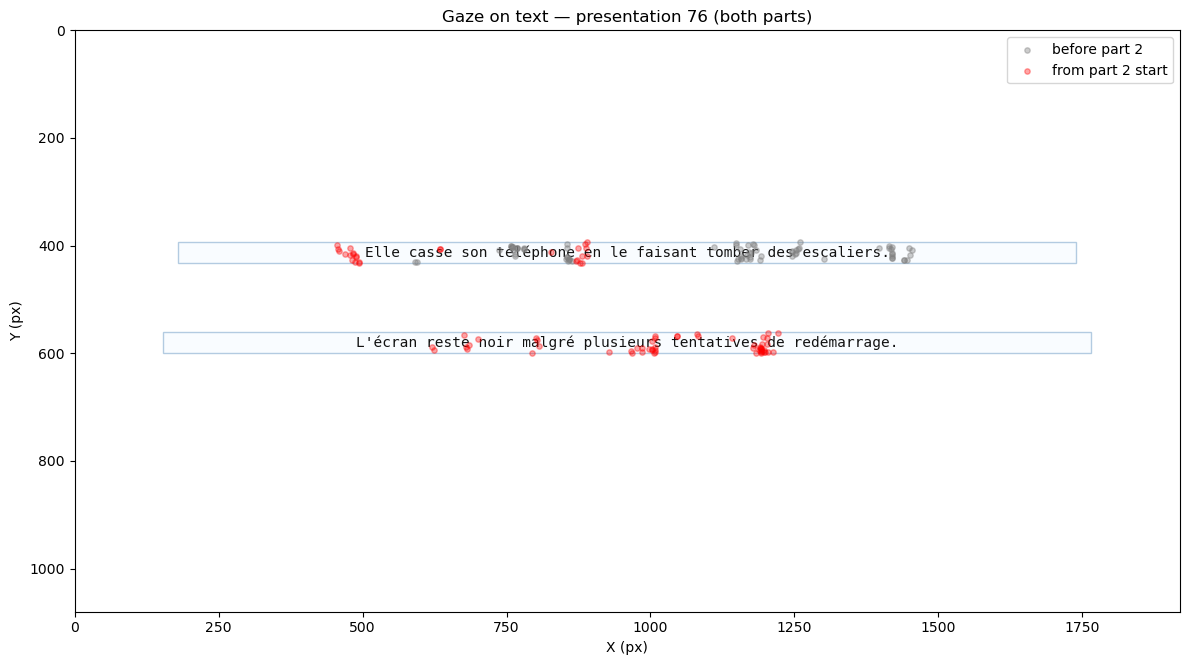

0.2222222222222222
saccade_type
progressive               7
within_line_regression    1
line_regression           1
Name: count, dtype: int64


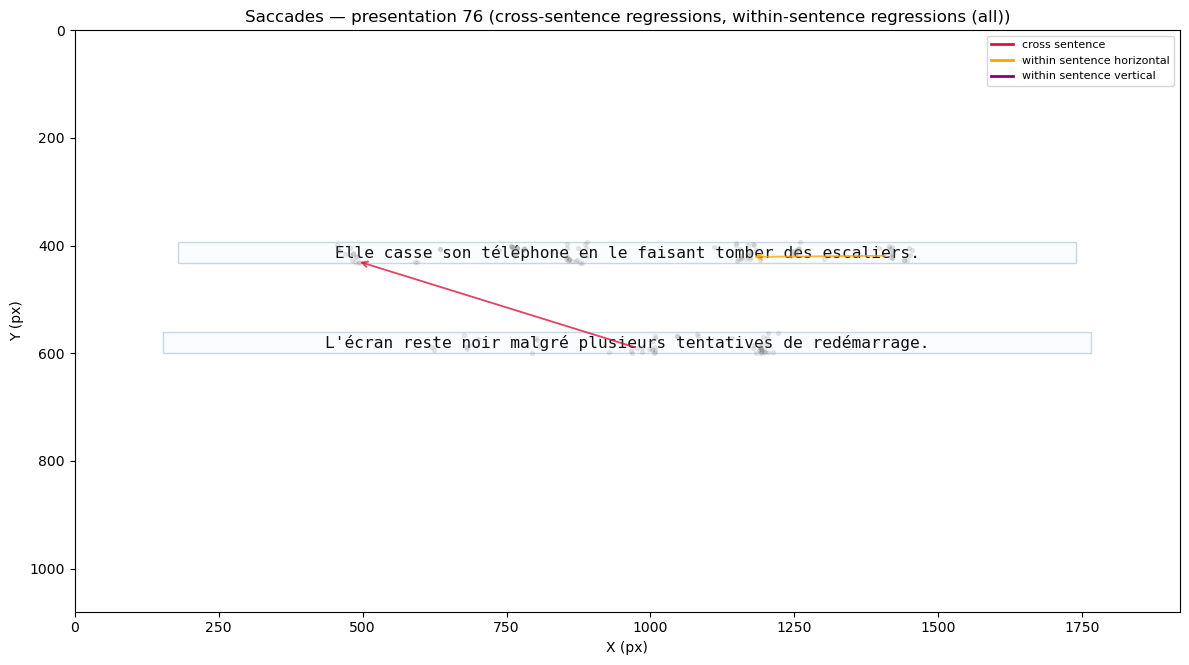

In [34]:
presentation = 76

results = gaze.gaze_on_screen(df_pos_mapped)

gaze.plot_gaze_on_text(df_pos_mapped, pres=presentation, results=results)

sacc = gaze.saccades_movement(pres=presentation, df_position=df_pos_mapped)
print(sacc["is_regression"].mean())
print(sacc["saccade_type"].value_counts())

gaze.plot_saccades_on_text(
    df_pos_mapped,
    pres=presentation,
    saccades=sacc,
    show_gaze=True,
    results=results,
)

In [35]:
stats = gaze.gaze_fix_stats(df_pos_mapped)

In [36]:
stats.head()

,presentation,n_fixations_sentence1,n_fixations_sentence2,horizontal_regressions_sentence1,vertical_regressions_sentence1,horizontal_regressions_sentence2,vertical_regressions_sentence2,horizontal_regressions_sentence1_after_sentence2,vertical_regressions_sentence1_after_sentence2,cross_sentence_regressions,gaze_samples_sentence1_after_sentence2
0,0,2,3,0,0,0,0,0,0,1,34
1,1,1,2,0,0,1,0,0,0,1,40
2,2,0,1,0,0,0,0,0,0,0,2
3,3,0,2,0,0,0,0,0,0,0,1
4,4,0,1,0,0,0,0,0,0,0,2


### analysis / plots

In [37]:
def add_conditions(stats, df_pos_mapped, conditions_df):
    """Attach real_index + condition labels to gaze_fix_stats output."""
    pres_to_real = (
        df_pos_mapped[["presentation_index", "real_index"]]
        .drop_duplicates()
        .rename(columns={"presentation_index": "presentation"})
    )
    df = stats.merge(pres_to_real, on="presentation", how="left")
    df["real_index"] = df["real_index"].astype("Int64")

    conditions_df = conditions_df.copy()
    conditions_df.columns = [col.strip() for col in conditions_df.columns]

    condition_cols = ["real_index", "Uncertainty", "Resolution", "Unc Valence", "Res Valence"]
    condition_lookup = (
        conditions_df[condition_cols]
        .drop_duplicates(subset=["real_index"])
        .copy()
    )
    condition_lookup["real_index"] = condition_lookup["real_index"].astype("Int64")

    df = df.merge(condition_lookup, on="real_index", how="left")
    df = df.drop_duplicates(subset=["presentation"]).reset_index(drop=True)

    return df.dropna(subset=["Uncertainty", "Resolution", "Unc Valence", "Res Valence"])

In [38]:
def plot_total_fixations_by_condition(df, metric="n_fixations_sentence1", ylabel="Total fixations"):
    """Bar chart of summed metric values, one subplot per existing Uncertainty x
    Resolution combination. Within each subplot, bars are grouped by Res Valence
    (x-axis) and colored by Unc Valence (green = positive, red = negative)."""
    unc_val_order = [v for v in sorted(df["Unc Valence"].dropna().unique(), key=str.lower)]
    res_val_order = [v for v in sorted(df["Res Valence"].dropna().unique(), key=str.lower)]

    def valence_color(v):
        v_str = str(v).lower()
        if v_str.startswith("pos"):
            return "seagreen"
        if v_str.startswith("neg"):
            return "firebrick"
        return "gray"

    def _sort_key(val):
        if pd.isna(val):
            return 999
        val_str = str(val).lower()
        if val_str in {"high", "h"}:
            return 0
        if val_str in {"low", "l"}:
            return 1
        return 999

    totals = (
        df.groupby(["Uncertainty", "Resolution", "Unc Valence", "Res Valence"], dropna=False)[metric]
        .sum()
        .reset_index()
    )

    combos = (
        totals[["Uncertainty", "Resolution"]]
        .drop_duplicates()
        .assign(
            unc_key=lambda s: s["Uncertainty"].map(_sort_key),
            res_key=lambda s: s["Resolution"].map(_sort_key),
        )
        .sort_values(["unc_key", "res_key", "Uncertainty", "Resolution"])
        .drop(columns=["unc_key", "res_key"])
        .itertuples(index=False, name=None)
    )
    combos = list(combos)

    n = len(combos)
    ncols = min(2, n) if n > 1 else 1
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    n_unc = len(unc_val_order)
    bar_width = 0.8 / max(1, n_unc)
    x_base = np.arange(len(res_val_order))

    for ax_idx, (unc, res) in enumerate(combos):
        ax = axes_flat[ax_idx]
        sub = totals[(totals["Uncertainty"] == unc) & (totals["Resolution"] == res)].copy()

        pivot = (
            sub.pivot_table(
                index="Res Valence",
                columns="Unc Valence",
                values=metric,
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(index=res_val_order, columns=unc_val_order, fill_value=0)
        )

        for i, unc_val in enumerate(unc_val_order):
            heights = pivot[unc_val].to_numpy()
            offset = (i - (n_unc - 1) / 2) * bar_width
            ax.bar(
                x_base + offset,
                heights,
                width=bar_width,
                color=valence_color(unc_val),
                label=f"Unc Valence: {unc_val}",
                edgecolor="black",
                linewidth=0.5,
            )

        ax.set_xticks(x_base)
        ax.set_xticklabels(res_val_order)
        ax.set_xlabel("Res Valence")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Uncertainty: {unc} | Resolution: {res}")

        handles, labels = ax.get_legend_handles_labels()
        seen = dict(zip(labels, handles))
        ax.legend(seen.values(), seen.keys(), fontsize=8)

    for j in range(len(combos), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{ylabel} by condition ({metric})", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return fig


In [39]:
conditions_df = pd.read_excel("data/sentences_newconditions.xlsx")
conditions_df.columns = [col.strip() for col in conditions_df.columns]
conditions_df = conditions_df.reset_index(drop=True)
conditions_df["real_index"] = conditions_df.index

stats = gaze.gaze_fix_stats(df_pos_mapped)
df = add_conditions(stats, df_pos_mapped, conditions_df)

print(df.shape)
print(df["Uncertainty"].unique())
print(df["Resolution"].unique())

(96, 16)
<StringArray>
['Low', 'High']
Length: 2, dtype: str
<StringArray>
['Low', 'High']
Length: 2, dtype: str


In [40]:
# conditions_df = pd.read_excel(
#     "data/sentences_newconditions.xlsx"
# )

# conditions_df.columns = [col.strip() for col in conditions_df.columns]

# # real_index = row order, 0-indexed to match df_pos_mapped's real_index convention
# conditions_df = conditions_df.reset_index(drop=True)
# conditions_df["real_index"] = conditions_df.index

# stats = gaze.gaze_fix_stats(df_pos_mapped)
# df = add_conditions(stats, df_pos_mapped, conditions_df)

In [41]:
# print(conditions_df.head(20))
# print(conditions_df["real_index"].value_counts())
# # print(conditions_df.groupby("real_index")[["Uncertainty", "Resolution", "Unc Valence", "Res Valence"]].nunique())

In [42]:
# def quick_na_report(df, name):
#     print(f"\n=== {name} ===")
#     print("shape:", df.shape)
#     na_counts = df.isna().sum()
#     na_counts = na_counts[na_counts > 0]
#     if na_counts.empty:
#         print("No NaNs found.")
#     else:
#         print("NaN counts per column:")
#         print(na_counts)
#         # show a few offending rows for the worst column
#         worst_col = na_counts.idxmax()
#         print(f"\nSample rows with NaN in '{worst_col}':")
#         print(df[df[worst_col].isna()].head())

# quick_na_report(stats, "stats")
# quick_na_report(df_pos_mapped, "df_pos_mapped")
# quick_na_report(conditions_df, "conditions_df")

# # Specifically check real_index / presentation ranges and duplicates,
# # since that's what's driving the merge issue
# print("\n=== real_index / presentation ranges ===")
# print("stats['presentation'] range:", stats["presentation"].min(), "-", stats["presentation"].max())
# print("df_pos_mapped['presentation_index'] range:", df_pos_mapped["presentation_index"].min(), "-", df_pos_mapped["presentation_index"].max())
# print("df_pos_mapped['real_index'] range:", df_pos_mapped["real_index"].min(), "-", df_pos_mapped["real_index"].max())
# print("conditions_df real_index range:", conditions_df["real_index"].min() if "real_index" in conditions_df else conditions_df["Number"].min(),
#       "-", conditions_df["real_index"].max() if "real_index" in conditions_df else conditions_df["Number"].max())

# print("\n=== duplicate checks ===")
# print("stats duplicated presentation:", stats["presentation"].duplicated().sum())
# print("df_pos_mapped duplicated (presentation_index, real_index):",
#       df_pos_mapped[["presentation_index", "real_index"]].drop_duplicates()["presentation_index"].duplicated().sum())
# print("conditions_df duplicated real_index:",
#       (conditions_df["real_index"] if "real_index" in conditions_df else conditions_df["Number"]).duplicated().sum())

In [43]:
def plot_total_fixations_by_condition(df, metric="n_fixations_sentence1", ylabel="Total fixations"):
    """Bar chart of SUMMED metric values, one subplot per existing Uncertainty x
    Resolution combination. Within each subplot, four bars covering all
    Unc Valence x Res Valence combinations."""

    totals = df.groupby(["Uncertainty", "Resolution", "Unc Valence", "Res Valence"])[metric].sum().reset_index()

    combos = totals[["Uncertainty", "Resolution"]].drop_duplicates().sort_values(
        ["Uncertainty", "Resolution"]
    ).itertuples(index=False, name=None)
    combos = list(combos)

    n = len(combos)
    ncols = min(2, n) if n > 1 else 1
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False, sharey=True)
    axes_flat = axes.flatten()

    # All four Unc Valence x Res Valence combinations
    bar_specs = [
        ("pos", "pos", "Unc+ / Res+", "mediumseagreen"),
        ("pos", "neg", "Unc+ / Res−", "seagreen"),
        ("neg", "pos", "Unc− / Res+", "salmon"),
        ("neg", "neg", "Unc− / Res−", "firebrick"),
    ]
    bar_labels = [spec[2] for spec in bar_specs]
    bar_colors = [spec[3] for spec in bar_specs]

    def get_val(sub, unc_val_prefix, res_val_prefix):
        row = sub[
            sub["Unc Valence"].str.lower().str.startswith(unc_val_prefix)
            & sub["Res Valence"].str.lower().str.startswith(res_val_prefix)
        ]
        return row[metric].sum() if not row.empty else 0

    # First pass: compute all heights so we can set a shared y-limit
    all_heights = []
    subplot_data = []
    for unc, res in combos:
        sub = totals[(totals["Uncertainty"] == unc) & (totals["Resolution"] == res)]
        heights = [get_val(sub, u, r) for u, r, _, _ in bar_specs]
        subplot_data.append((unc, res, heights))
        all_heights.extend(heights)

    y_max = max(all_heights) * 1.1 if all_heights else 1

    # Second pass: plot with shared y-axis
    for ax_idx, (unc, res, heights) in enumerate(subplot_data):
        ax = axes_flat[ax_idx]
        ax.bar(bar_labels, heights, color=bar_colors, edgecolor="black", linewidth=0.5)
        ax.set_ylim(0, y_max)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Uncertainty: {unc} | Resolution: {res}")
        ax.tick_params(axis="x", rotation=15)

    for j in range(len(combos), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"{ylabel} by condition ({metric})", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return

In [44]:
stats.columns

Index(['presentation', 'n_fixations_sentence1', 'n_fixations_sentence2',
       'horizontal_regressions_sentence1', 'vertical_regressions_sentence1',
       'horizontal_regressions_sentence2', 'vertical_regressions_sentence2',
       'horizontal_regressions_sentence1_after_sentence2',
       'vertical_regressions_sentence1_after_sentence2',
       'cross_sentence_regressions', 'gaze_samples_sentence1_after_sentence2'],
      dtype='str')

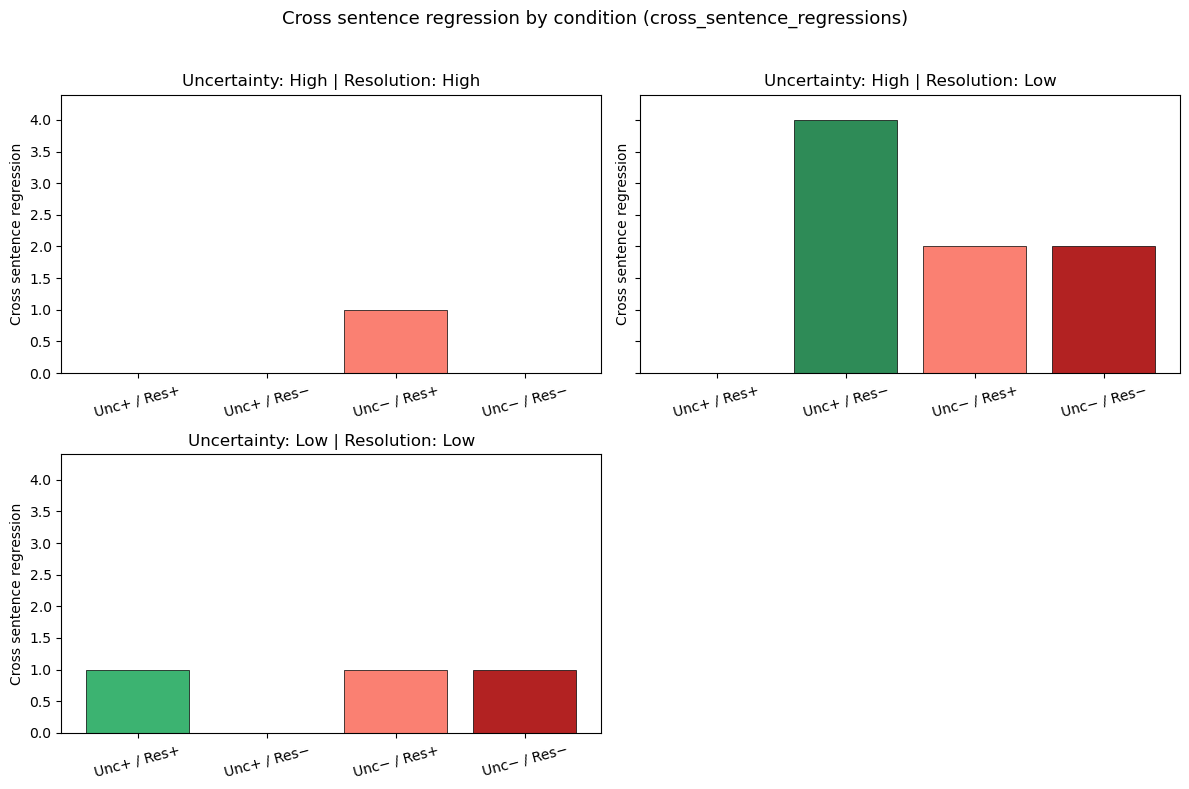

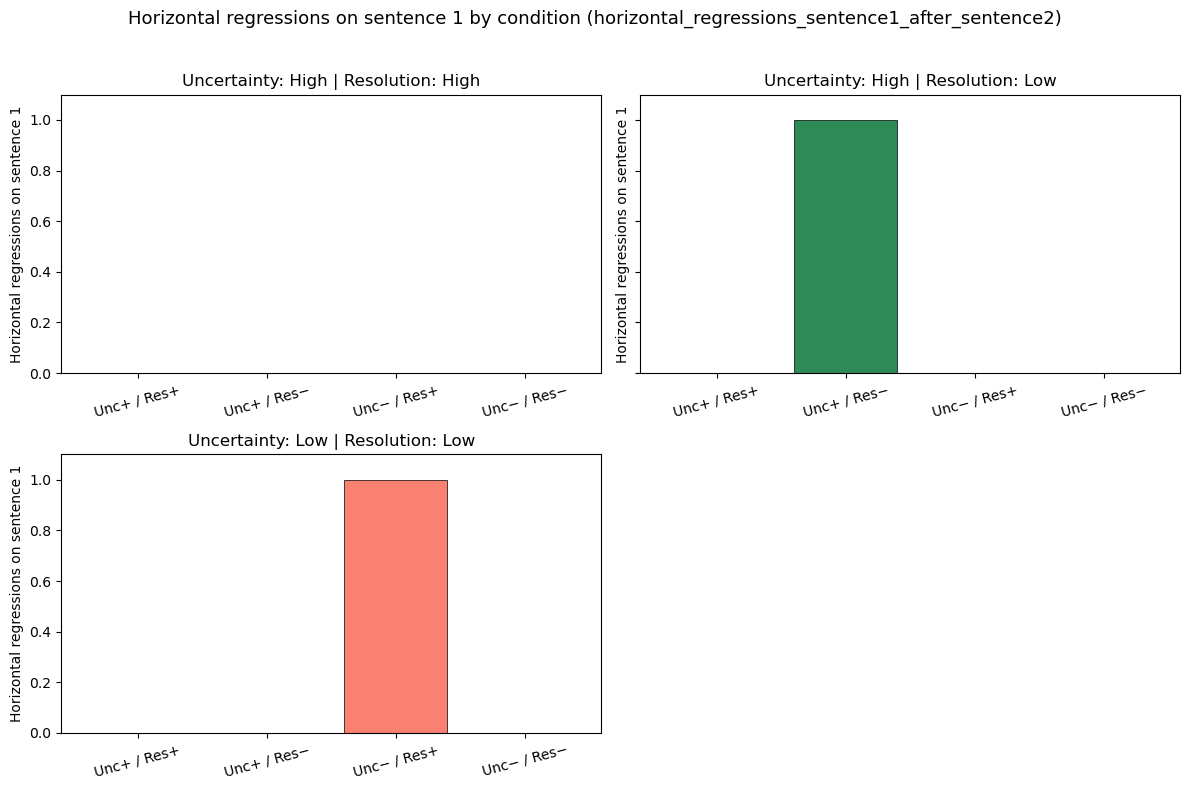

In [45]:
plot_total_fixations_by_condition(df, metric="cross_sentence_regressions", ylabel="Cross sentence regression")
plot_total_fixations_by_condition(df, metric="horizontal_regressions_sentence1_after_sentence2", ylabel="Horizontal regressions on sentence 1")


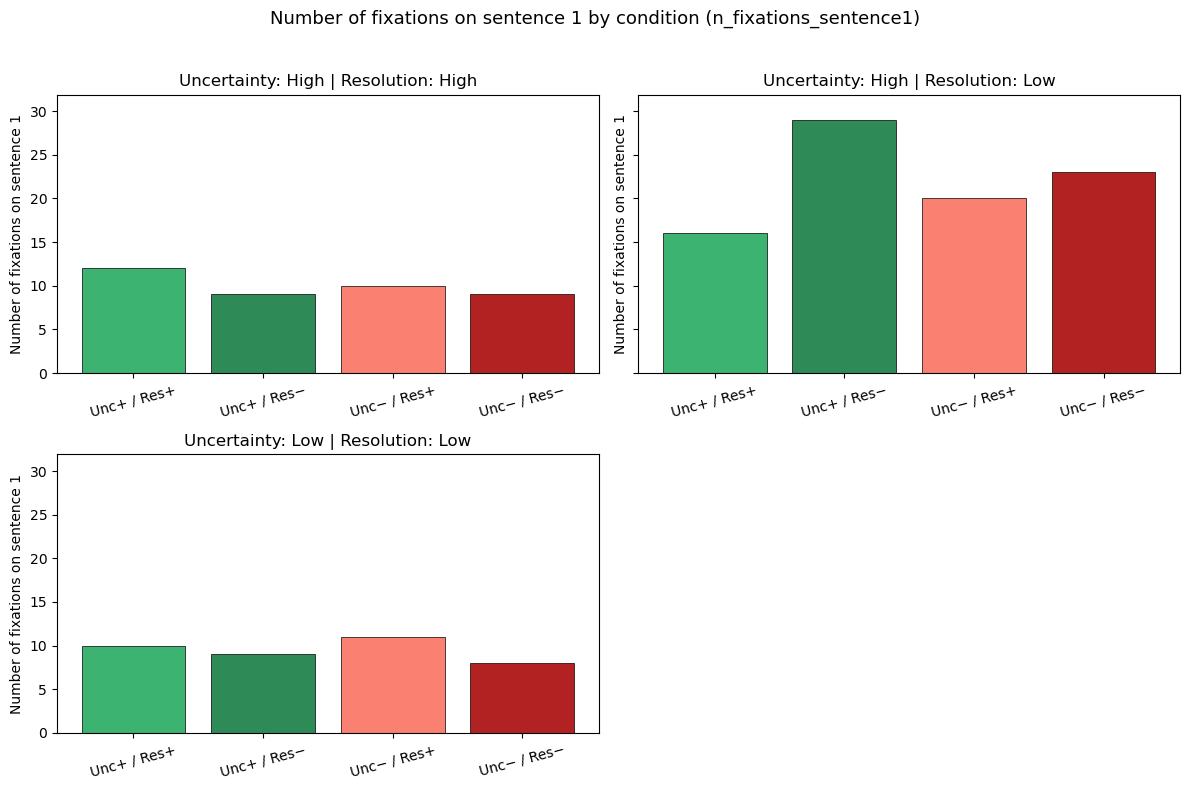

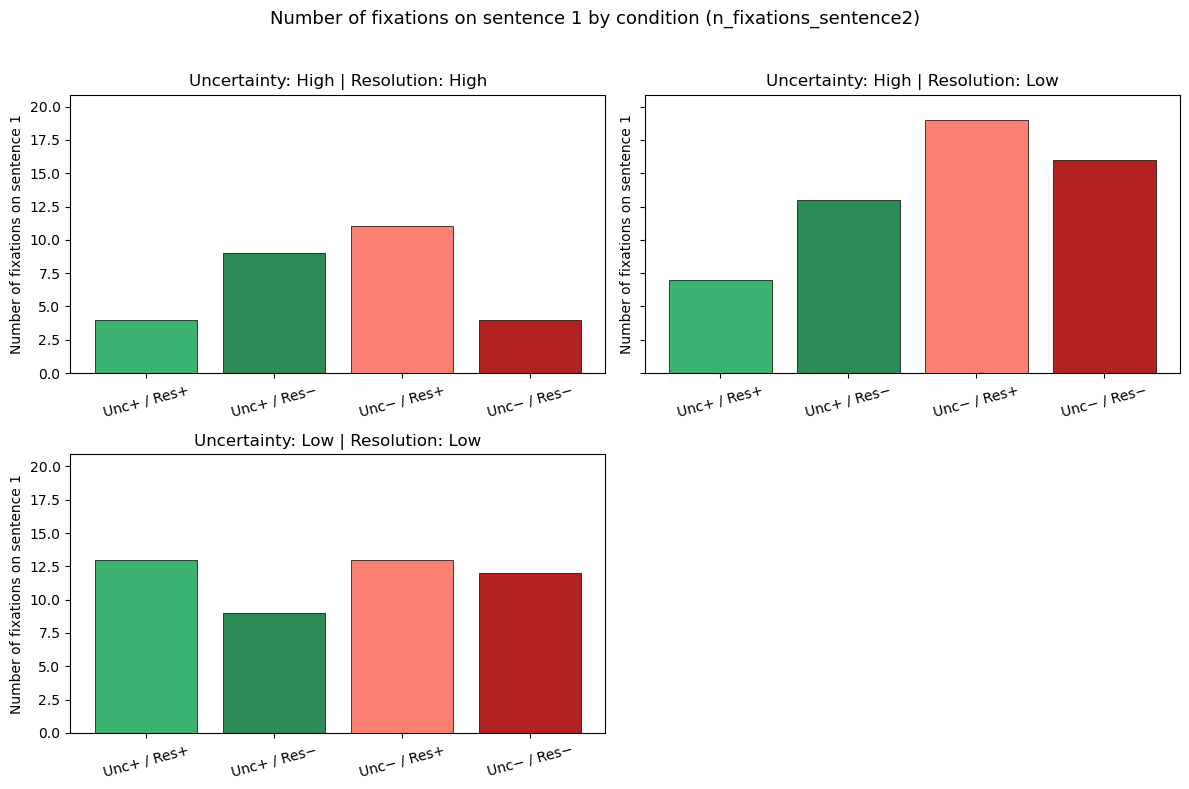

In [46]:
plot_total_fixations_by_condition(df, metric="n_fixations_sentence1", ylabel="Number of fixations on sentence 1")
plot_total_fixations_by_condition(df, metric="n_fixations_sentence2", ylabel="Number of fixations on sentence 1")
